## Speeches targeted for the general public

In [1]:
! pip install openpyxl
! pip install wordcloud

In [1]:
import openpyxl as open 
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt 
import nltk
from nltk.corpus import stopwords


In [2]:
# Charger le fichier Excel
data = pd.read_excel(
    "/home/onyxia/work/nlp_central_banks/data/general_audience_speeches.xlsx",  
    header=None,                      
    names=["Institution", "Date", "Speech"]        
)

In [11]:
data = data.iloc[1:].reset_index(drop=True)
data.head()

,Institution,Date,Speech
0,ECB,2025-12-18 00:00:00,"We kept our key interest rates unchanged. We did this because inflation is on track to settle around our 2% target.The economy is doing better than expected\n\nMany people have jobs and wages are increasing. People are spending more. Companies, too, are increasing their investments. Exports, especially chemicals, have also held up so far. Services should continue to drive the economy. Inflation is around 2% – our target\n\nEnergy is cheaper than a year ago. Food prices are increasing, but more slowly. The prices of many services are still going up relatively fast, but prices for goods are rising much more slowly. Looking ahead, we expect inflation to remain around our target.Banks are in good shape to cope with difficulties\n\nTheir financial positions are solid and they are making profits. But if prices in financial markets come down very suddenly, this could make life more challenging. So financial risks need to be watched closely and properly managed."
1,ECB,2025-10-30 00:00:00,"We kept our key interest rates unchanged We did this because inflation is settling around our 2% target. The global environment remains a drag on the economy...\n\nManufacturing firms are feeling the effects of higher tariffs, heightened uncertainty and a stronger euro. Exporters have fewer orders from abroad. …but at home things are looking better\n\nServices are doing well. Tourism is strong. More firms are investing in new IT systems and using AI in their operations. Many people are in jobs and have more money to spend\n\nConsumers are saving more than usual. That gives them more room for spending later. And with governments spending more on defence and infrastructure, this should all eventually give a boost to the economy.Inflation is close to our 2% target\n\nWages are rising less than before. Energy prices continue to fall, though more slowly than before. These developments are helping to stabilise inflation at our 2% target."
2,ECB,2025-09-11 00:00:00,"We kept our key interest rates unchanged We did this because inflation is set to stabilise at around our 2% target. The economy is navigating difficulties coming especially from abroad…\n\nHigher tariffs, a stronger euro and competition from other countries weigh on businesses – even if recent trade agreements have reduced uncertainty somewhat. …but there is momentum for stronger growth ahead\n\nLots of people are in work and many have had pay rises. This allows them to spend more, which lifts economic growth. Governments spending more on infrastructure and defence will also support the economy. Inflation is close to our 2% target\n\nFood prices have been rising more slowly and energy prices are lower than a year ago. Wages are no longer going up so much. All of this helps inflation to stabilise around 2%. We expect the economy to grow moderately but steadily in the years ahead We expect inflation to settle at around our 2% target"
3,ECB,2025-07-24 00:00:00,"We kept our key interest rates unchanged\n\nWe did this because inflation is set to stabilise at our 2% target. The economy has been resilient\n\nIt grew more strongly than expected over the first months of the year. But the global environment remains exceptionally uncertain, especially because of trade disputes. Firms are still holding back\n\nTariffs and global uncertainty are making them cautious to invest. The stronger euro means that firms’ exports are more expensive in the rest of the world. But governments are planning to spend more money, especially on defence and infrastructure, which should support the economy. Most people’s finances are in good shape\n\nMany people are in jobs and their wages are growing at a good pace. This allows them to spend on goods and services, like holidays, and to invest in buying a home. Borrowing money has become less expensive\n\nFirms are demanding slightly more credit. At the same time, banks are cautious about lending because of global uncertainty

In [12]:
# Print examples of the articles
pd.set_option('display.max_colwidth', None)
# YOUR CODE HERE
data.sample(5, random_state=42)

Institution                 Date  \
44         BoE  2024-12-19 00:00:00   
53         BoE  2023-11-02 00:00:00   
30         ECB  2022-03-10 00:00:00   
12         ECB  2024-06-06 00:00:00   
49         BoE  2024-05-09 00:00:00   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        

[nltk_data] Downloading package stopwords to /home/onyxia/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


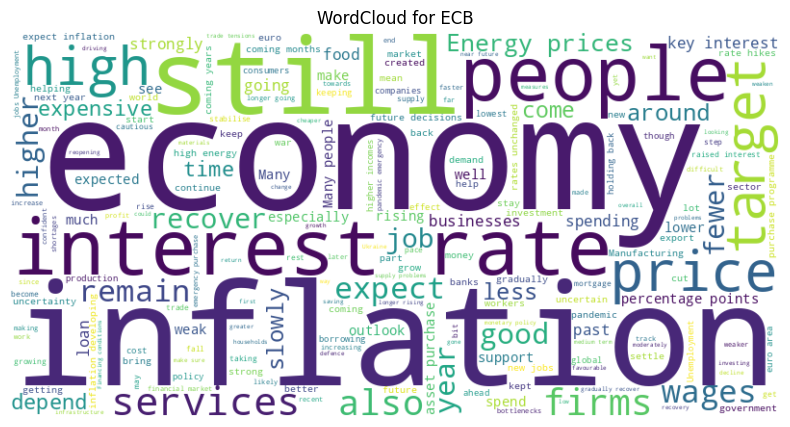

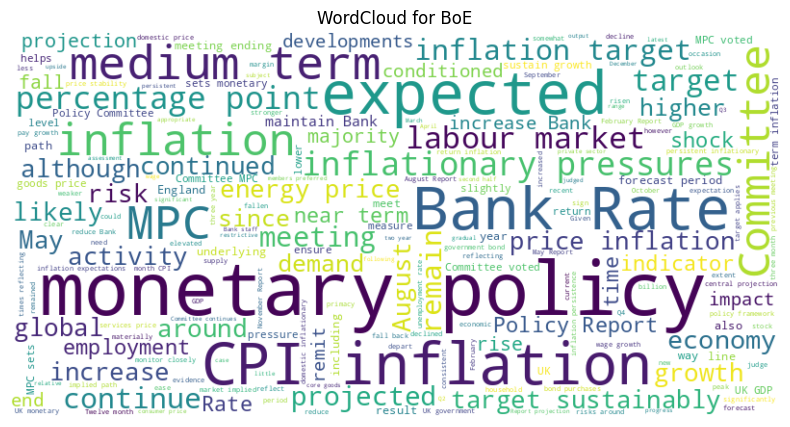

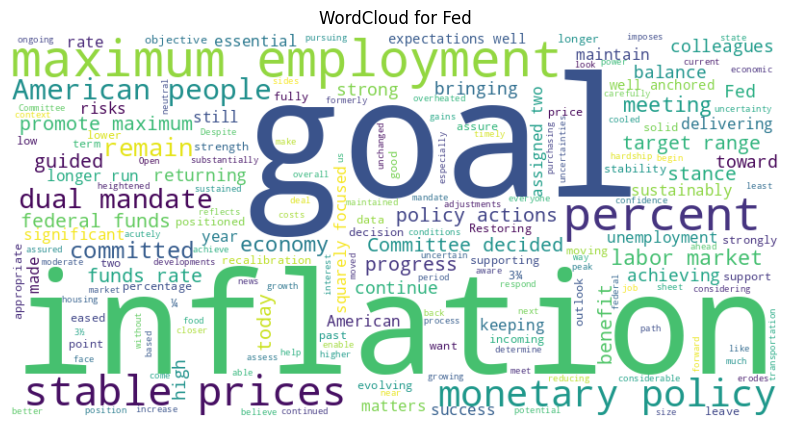

In [9]:
nltk.download('stopwords')
# Stopwords en anglais
stop_words = set(stopwords.words('english'))


for cat in ['ECB', 'BoE', 'Fed']:
    
    # Sélection des discours par institution
    text_cat = " ".join(
        data.loc[data["Institution"] == cat, "Speech"].dropna()
    )
    
    # WordCloud
    wc = WordCloud(
        width=800,
        height=400,
        background_color="white",
        stopwords=stop_words,
        max_words=200
    ).generate(text_cat)
    
    # Plot
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"WordCloud for {cat}")
    plt.show()


## Classic speeches 
This dataset comes from this article : Campiglio, E., Deyris, J., Romelli, D. and Scalisi, G., 2025. Warning words in a warming world: Central bank communication and climate change. European Economic Review [Open Access], Vol 178.

In [3]:
# Stockage et lecture des fichiers
import os
import requests
import s3fs

In [4]:
# Database of Campiglio, Deyris, Romelli and Scalisi (saved in the SSP Cloud, too heavy for github) :
MY_BUCKET = "lelkamel"
fs = s3fs.S3FileSystem(
    client_kwargs={"endpoint_url": "https://minio.lab.sspcloud.fr"}
)

files_url = f"{MY_BUCKET}/"

fs.get(f"{MY_BUCKET}/","", recursive=True)

# Lecture
specialized_speeches = pd.read_csv("CBS_dataset_v1.0.csv")

Checking the data

In [5]:
specialized_speeches["Date"] = pd.to_datetime(specialized_speeches["Date"])
specialized_speeches["Year"] = specialized_speeches["Date"].dt.year
specialized_speeches = specialized_speeches[specialized_speeches["Year"] > 2000]

In [6]:
# --- check for missing values ---
print("Missing values in each column:")
print(specialized_speeches.isnull().sum())

Missing values in each column:
URL               1646
PDF               9985
Title                0
Subtitle         11398
Date                 0
Authorname           0
Role                 0
Gender               0
CentralBank          0
Country              0
text                 0
text_original    26578
Filename             0
Language             0
Source               0
Year                 0
dtype: int64


In [7]:
countries_selected = [
    "USA",
    "GBR",
    "ECB"
]
specialized_speeches_filtered = specialized_speeches[
    specialized_speeches["Country"].isin(countries_selected)
]


I make sure there are no errors in the data

In [8]:
count_institutions = (
    specialized_speeches_filtered
    .groupby("Country")["CentralBank"]
    .nunique()
)
print(count_institutions)

Country
ECB     1
GBR     1
USA    13
Name: CentralBank, dtype: int64


In [9]:
us_counts = (
    specialized_speeches_filtered[
        specialized_speeches_filtered["Country"] == "USA"
    ]
    .groupby("CentralBank")
    .size()
    .sort_values(ascending=False)
)

print(us_counts)

CentralBank
Board of Governors of the Federal Reserve    1680
Federal Reserve Bank of New York              524
Federal Reserve Bank of Chicago               275
Federal Reserve Bank of Philadelphia          266
Federal Reserve Bank of Richmond              252
Federal Reserve Bank of San Francisco         240
Federal Reserve Bank of Dallas                211
Federal Reserve Bank of Cleveland             211
Federal Reserve Bank of Atlanta               209
Federal Reserve Bank of Boston                205
Federal Reserve Bank of St Louis              163
Federal Reserve Bank of Kansas City           157
Federal Reserve Bank of Minneapolis           144
dtype: int64


Should we include regional banks'speeches ? I let them in the dataset for now.

### Some descriptive statistics

Do some instutions speak more than others ? Who speaks ?

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

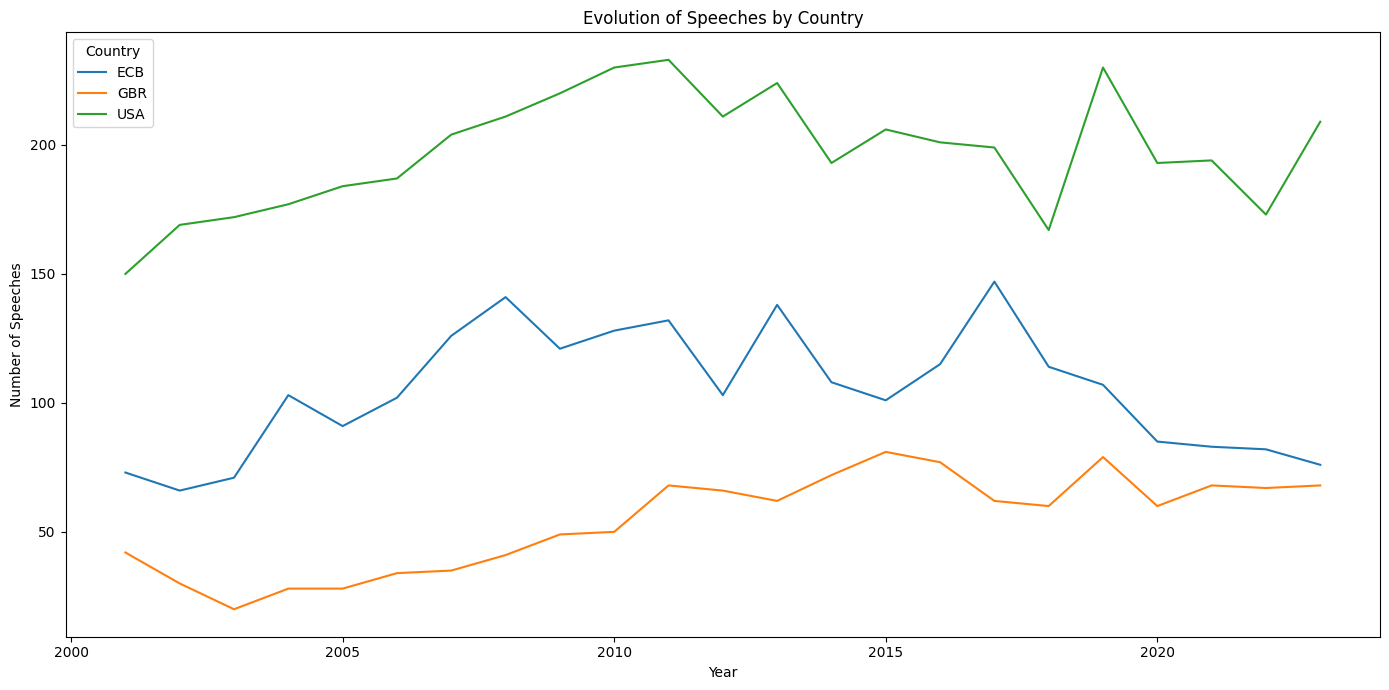

In [ ]:


df = specialized_speeches_filtered.copy()


for col in ['Country', 'Gender', 'Role']:
    df[col] = df[col].astype(str).str.strip()

top_countries = df['Country'].value_counts().index
top_roles = df['Role'].value_counts().index

df_country = df[df['Country'].isin(top_countries)]
df_role = df[df['Role'].isin(top_roles)]

# Country evolution
country_year = df_country.groupby(['Year', 'Country']).size().unstack(fill_value=0)
plt.figure(figsize=(14, 7))
country_year.plot(ax=plt.gca())
plt.title('Evolution of Speeches by Country')
plt.xlabel('Year')
plt.ylabel('Number of Speeches')
plt.tight_layout()
plt.show()


What about document's lenght ?

In [3]:
import numpy as np
from textstat import flesch_reading_ease
import seaborn as sns

In [4]:
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize

nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /home/onyxia/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [5]:
import pydantic
import spacy
import thinc

print("pydantic:", pydantic.__version__)
print("spacy:", spacy.__version__)
print("thinc:", thinc.__version__)

nlp = spacy.load("en_core_web_sm")
print("OK")

pydantic: 2.12.5
spacy: 3.8.11
thinc: 8.3.11
OK


In [13]:
#Varable to study speech complexity
df['word_count'] = df['text'].apply(lambda x: len(word_tokenize(x))) #3min
df['char_count'] = df['text'].apply(len)
df['sentence_count'] = df['text'].apply(lambda x: len(sent_tokenize(x)))
df['avg_word_length'] = df['text'].apply(lambda x: np.mean([len(word) for word in word_tokenize(x)]) if len(word_tokenize(x)) > 0 else 0)
df['avg_sentence_length'] = df['word_count'] / df['sentence_count']
df['flesch_score'] = df['text'].apply(lambda x: flesch_reading_ease(x))

In [6]:
df = pd.read_csv('/home/onyxia/work/nlp_central_banks/lyna_work/speeches_cleaned.csv')

In [7]:
# -----------------------------
# 3. Function to compute dependency depth of one sentence
# -----------------------------
def sentence_dependency_depth(sent):
    """
    Depth = longest path from sentence root to any terminal node (leaf).
    We count nodes on the path, so a root->child->grandchild path has depth 3.
    """
    root = sent.root

    def depth_from_token(token):
        children = list(token.children)
        if not children:
            return 1
        return 1 + max(depth_from_token(child) for child in children)

    return depth_from_token(root)

# -----------------------------
# 4. Function to compute speech-level dependency depth
# -----------------------------
def speech_dependency_depth(text):
    """
    Compute average sentence dependency depth for one speech.
    You could also use max(sentence depths) instead of mean if preferred.
    """
    doc = nlp(text)

    sentence_depths = []
    for sent in doc.sents:
        # skip extremely short / empty-like sentences
        sent_tokens = [tok for tok in sent if not tok.is_space]
        if len(sent_tokens) == 0:
            continue
        sentence_depths.append(sentence_dependency_depth(sent))

    if len(sentence_depths) == 0:
        return None

    return sum(sentence_depths) / len(sentence_depths)

#df['dependency_depth'] = df['text'].apply(speech_dependency_depth)
# Drop rows where parsing failed
#df = df.dropna(subset=['dependency_depth'])


In [8]:
import os
from tqdm import tqdm

output_file = "df_with_depth.csv"

# Reprise si fichier existe
if os.path.exists(output_file):
    df_saved = pd.read_csv(output_file)
    df['dependency_depth'] = df_saved['dependency_depth']
else:
    df['dependency_depth'] = None

# Boucle avec barre de progression
for i in tqdm(range(len(df)), desc="Processing speeches"):
    
    if pd.notnull(df.loc[i, 'dependency_depth']):
        continue  # skip déjà fait

    text = df.loc[i, 'text']
    
    try:
        depth = speech_dependency_depth(text)
    except Exception as e:
        depth = None
        print(f"\nError at index {i}: {e}")  # \n pour ne pas casser la barre

    df.loc[i, 'dependency_depth'] = depth

    # 💾 Sauvegarde tous les 10
    if i % 10 == 0:
        df.to_csv(output_file, index=False)

# Sauvegarde finale
df.to_csv(output_file, index=False)
print("Final save complete")

Processing speeches: 100%|██████████| 8197/8197 [21:20<00:00,  6.40it/s]  


Final save complete


In [9]:
df.to_csv('/home/onyxia/work/nlp_central_banks/lyna_work/speeches_cleaned.csv')

In [ ]:
#Tester !
df_without_regional_banks = df

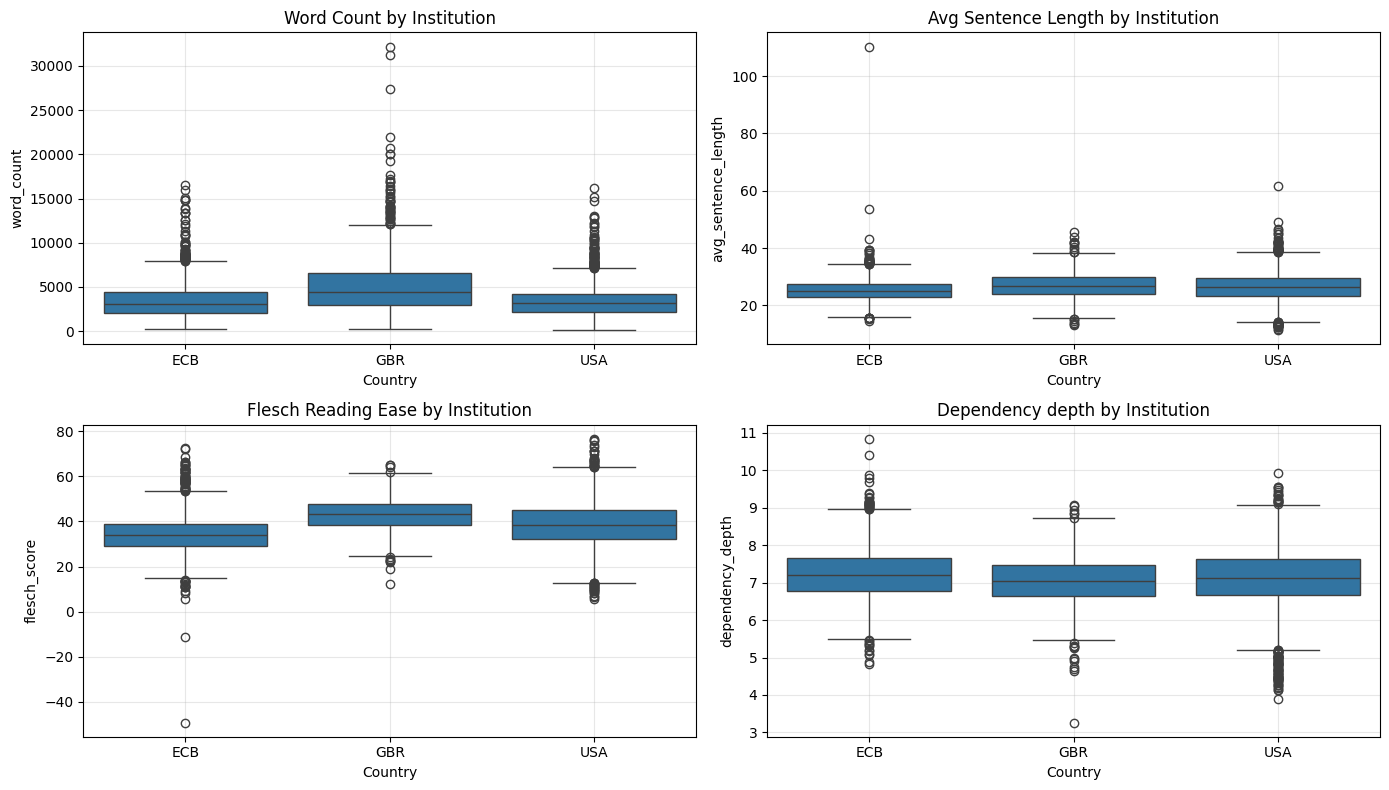

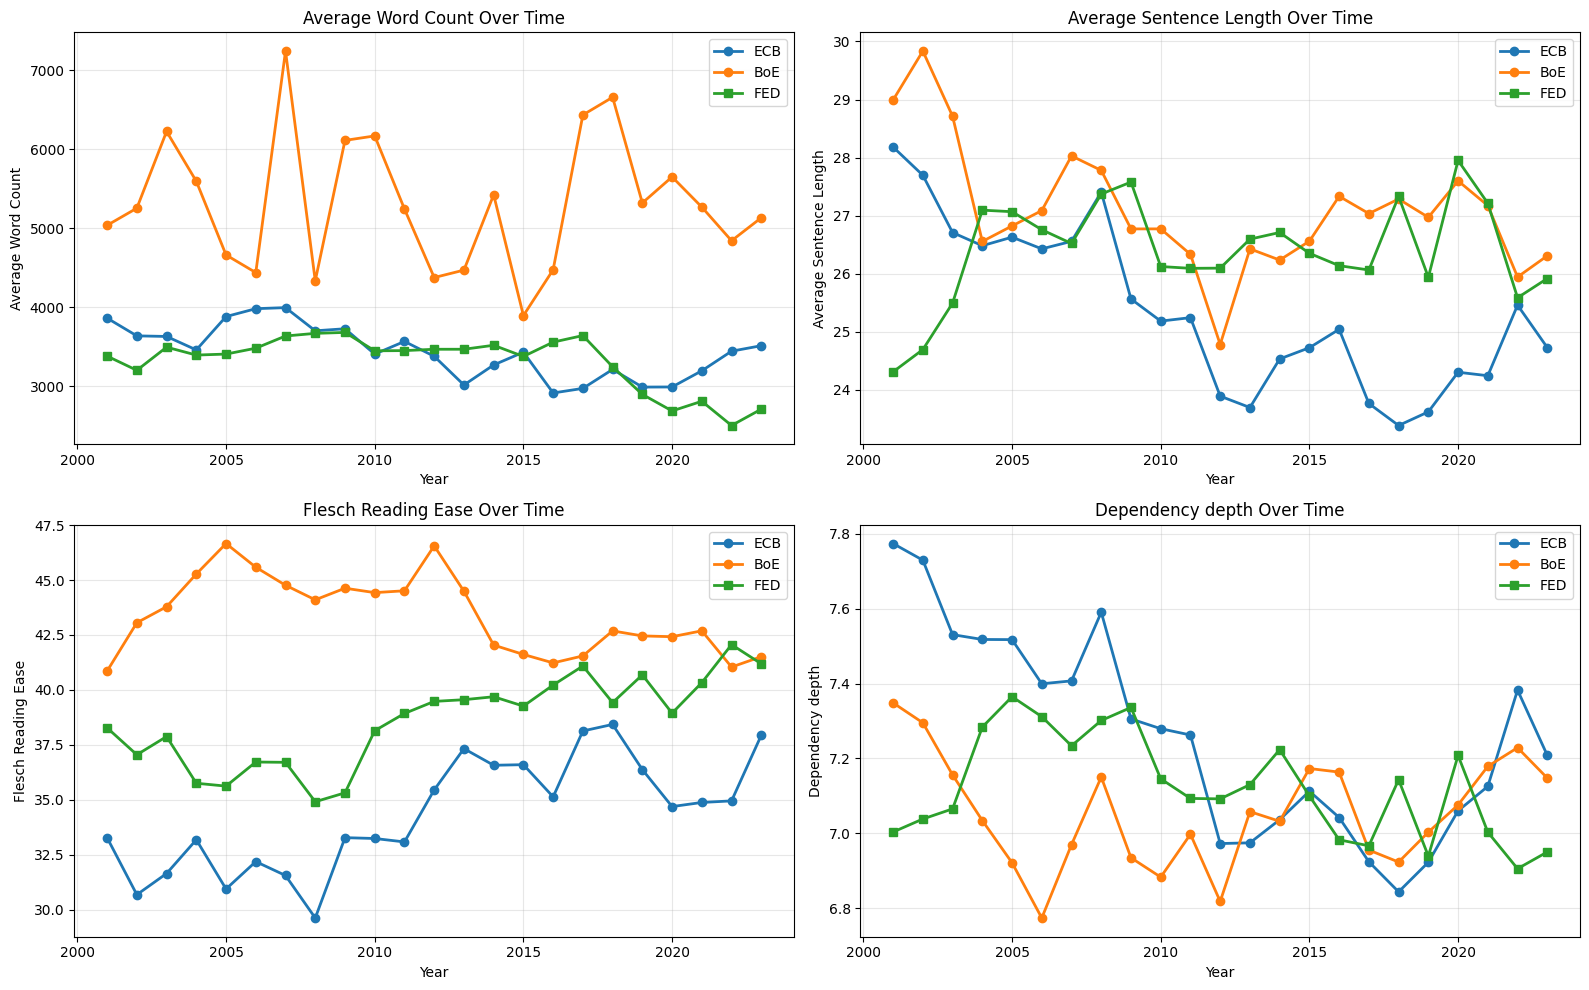

In [11]:
#Comparison of speech overall complexity
plt.figure(figsize=(14, 8))
metrics = ['word_count', 'avg_sentence_length', 'flesch_score', 'dependency_depth']
titles = ['Word Count', 'Avg Sentence Length', 'Flesch Reading Ease', "Dependency depth"]

for i, (metric, title) in enumerate(zip(metrics, titles)):
    plt.subplot(2, 2, i+1)
    sns.boxplot(data=df[df['Country'].isin(['ECB', "GBR", 'USA'])],
                x='Country', y=metric)
    plt.title(f'{title} by Institution')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/home/onyxia/work/nlp_central_banks/lyna_work/figures/speech_complexity_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

#Time evolution 
fig, axs = plt.subplots(2, 2, figsize=(16, 10))
years = df['Year'].astype(int)

# ECB trends
ecb_data = df[df['Country'] == 'ECB'].copy()
ecb_yearly = ecb_data.groupby('Year').agg({
    'word_count': 'mean',
    'avg_sentence_length': 'mean',
    'flesch_score': 'mean', 
    'dependency_depth': 'mean'
}).reset_index()

# BoE trends
BoE_data = df[df['Country'] == 'GBR'].copy()
BoE_yearly = BoE_data.groupby('Year').agg({
    'word_count': 'mean',
    'avg_sentence_length': 'mean',
    'flesch_score': 'mean',
    'dependency_depth': 'mean'
}).reset_index()

# FED trends
fed_data = df[df['Country'] == 'USA'].copy()
fed_yearly = fed_data.groupby('Year').agg({
    'word_count': 'mean',
    'avg_sentence_length': 'mean',
    'flesch_score': 'mean',
    'dependency_depth': 'mean'
}).reset_index()

# Plot trends
metrics = ['word_count', 'avg_sentence_length', 'flesch_score', "dependency_depth"]
titles = ['Average Word Count', 'Average Sentence Length', 'Flesch Reading Ease', 'Dependency depth']

for i, (metric, title) in enumerate(zip(metrics, titles)):
    ax = plt.subplot(2, 2, i+1)
    ax.plot(ecb_yearly['Year'], ecb_yearly[metric], marker='o', linewidth=2, label='ECB')
    ax.plot(BoE_yearly['Year'], BoE_yearly[metric], marker='o', linewidth=2, label='BoE')
    ax.plot(fed_yearly['Year'], fed_yearly[metric], marker='s', linewidth=2, label='FED')
    ax.set_title(f'{title} Over Time')
    ax.set_xlabel('Year')
    ax.set_ylabel(title)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.savefig('/home/onyxia/work/nlp_central_banks/lyna_work/figures/speech_complexity_trends.png', dpi=300, bbox_inches='tight')
plt.show()
     

So the speeches seem to be shorter across time (except for the UK). Now, how readable are they ? I start to study leaxical readability metrics (such as the Flesch-Kincaid scores which are widely used over the literature). However, as the International monetary fund working paper of june 2025 points out, although this metric **do** offer some general insights, it is unable to *capture the semantic content of communication (including the underlying economic rationale, policy intent or strategic framing)*. To get more insights, we will have to delve into a more in-depth analysis, using NLP tools.  

The Flesch-Kincaid Ease Score is calculated as:
$$
\text{Score } = 206.835-1.015(\frac{\text{ Total Words }}{\text{ Total Sentences }})-84.6(\frac{\text{ Total Syllables }}{\text{ Total Words }})
$$
The score ranges from 0 to 100, with higher values indicating better readability. In English-language texts, scores above 60 correspond to an 8th-grade reading level, while values between 30 and 50 suggest college-level complexity. Scores below 30 indicate highly technical or specialized content.

### Advanced text processing